In [1]:
import pandas as  pd

In [2]:
df = pd.read_csv("/content/drive/MyDrive/AIML_lab_sem4/exp 5,6,7/spam_email.csv")

In [3]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, confusion_matrix

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [6]:
df['Category'] = df['Category'].map({'spam': 1, 'ham': 0})
print(df.head())

   Category                                            Message
0         0  Go until jurong point, crazy.. Available only ...
1         0                      Ok lar... Joking wif u oni...
2         1  Free entry in 2 a wkly comp to win FA Cup fina...
3         0  U dun say so early hor... U c already then say...
4         0  Nah I don't think he goes to usf, he lives aro...


In [7]:
X = df['Message']
y = df['Category']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
vectorizer = TfidfVectorizer(stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [10]:
LR = LogisticRegression()
LR.fit(X_train_vec, y_train)

LogisticRegression()

In [11]:
NB = MultinomialNB()
NB.fit(X_train_vec, y_train)

MultinomialNB()

In [12]:
DT = DecisionTreeClassifier()
DT.fit(X_train_vec, y_train)

DecisionTreeClassifier()

In [13]:
RF = RandomForestClassifier()
RF.fit(X_train_vec, y_train)

RandomForestClassifier()

In [14]:
svc = SVC()
svc.fit(X_train_vec, y_train)

SVC()

In [15]:
LR_acc = accuracy_score(y_test, LR.predict(X_test_vec))
NB_acc = accuracy_score(y_test, NB.predict(X_test_vec))
DT_acc = accuracy_score(y_test, DT.predict(X_test_vec))
RF_acc = accuracy_score(y_test, RF.predict(X_test_vec))
svc_acc = accuracy_score(y_test, svc.predict(X_test_vec))

In [16]:
print("LR Accuracy: ", LR_acc)
print("NB Accuracy: ", NB_acc)
print("DT Accuracy: ", DT_acc)
print("RF Accuracy: ", RF_acc)
print("SVC Accuracy: ", svc_acc)

LR Accuracy:  0.967713004484305
NB Accuracy:  0.9766816143497757
DT Accuracy:  0.968609865470852
RF Accuracy:  0.9802690582959641
SVC Accuracy:  0.9847533632286996


In [17]:
LR_p = precision_score(y_test, LR.predict(X_test_vec))
NB_p = precision_score(y_test, NB.predict(X_test_vec))
DT_p = precision_score(y_test, DT.predict(X_test_vec))
RF_p = precision_score(y_test, RF.predict(X_test_vec))
svc_p = precision_score(y_test, svc.predict(X_test_vec))

In [18]:
print("LR Precision: ", LR_p)
print("NB Precision: ", NB_p)
print("DT Precision: ", DT_p)
print("RF Precision: ", RF_p)
print("SVC Precision: ", svc_p)

LR Precision:  1.0
NB Precision:  1.0
DT Precision:  0.9071428571428571
RF Precision:  1.0
SVC Precision:  1.0


In [19]:
LR_r = recall_score(y_test, LR.predict(X_test_vec))
NB_r = recall_score(y_test, NB.predict(X_test_vec))
DT_r = recall_score(y_test, DT.predict(X_test_vec))
RF_r = recall_score(y_test, RF.predict(X_test_vec))
svc_r = recall_score(y_test, svc.predict(X_test_vec))

In [20]:
print("LR Recall: ", LR_r)
print("NB Recall: ", NB_r)
print("DT Recall: ", DT_r)
print("RF Recall: ", RF_r)
print("SVC Recall: ", svc_r)

LR Recall:  0.7583892617449665
NB Recall:  0.825503355704698
DT Recall:  0.8523489932885906
RF Recall:  0.8523489932885906
SVC Recall:  0.8859060402684564


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

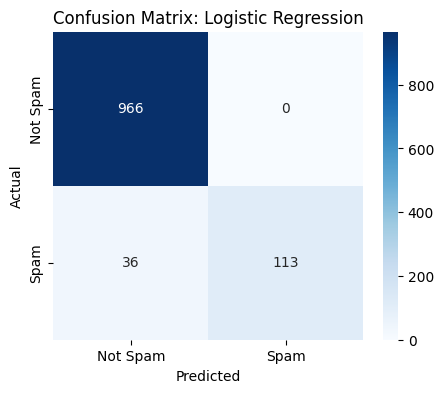

In [22]:
lr_cm = confusion_matrix(y_test, LR.predict(X_test_vec))
plt.figure(figsize=(5, 4))
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Spam', 'Spam'], yticklabels=['Not Spam', 'Spam'])
plt.title('Confusion Matrix: Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

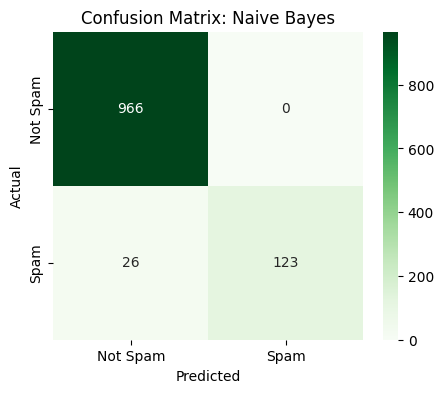

In [23]:
nb_cm = confusion_matrix(y_test, NB.predict(X_test_vec))
plt.figure(figsize=(5, 4))
sns.heatmap(nb_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Spam', 'Spam'], yticklabels=['Not Spam', 'Spam'])
plt.title('Confusion Matrix: Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

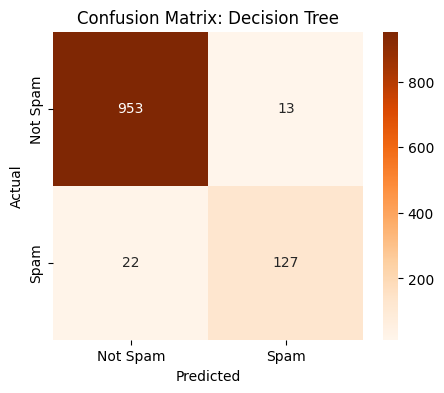

In [24]:
dt_cm = confusion_matrix(y_test, DT.predict(X_test_vec))
plt.figure(figsize=(5, 4))
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Spam', 'Spam'], yticklabels=['Not Spam', 'Spam'])
plt.title('Confusion Matrix: Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

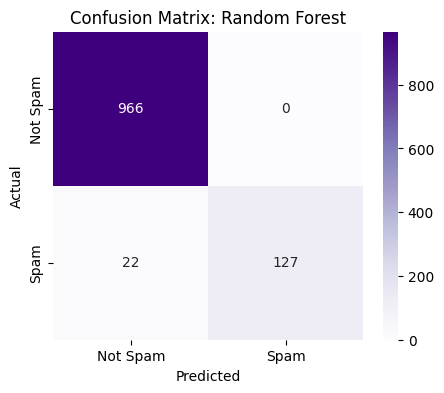

In [25]:
rf_cm = confusion_matrix(y_test, RF.predict(X_test_vec))
plt.figure(figsize=(5, 4))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Not Spam', 'Spam'], yticklabels=['Not Spam', 'Spam'])
plt.title('Confusion Matrix: Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

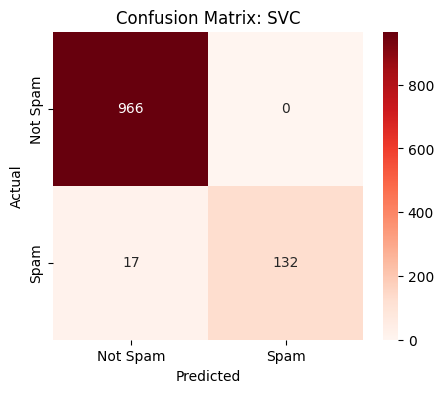

In [26]:
svc_cm = confusion_matrix(y_test, svc.predict(X_test_vec))
plt.figure(figsize=(5, 4))
sns.heatmap(svc_cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Not Spam', 'Spam'], yticklabels=['Not Spam', 'Spam'])
plt.title('Confusion Matrix: SVC')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [27]:
from sklearn.metrics import f1_score

LR_f1 = f1_score(y_test, LR.predict(X_test_vec))
NB_f1 = f1_score(y_test, NB.predict(X_test_vec))
DT_f1 = f1_score(y_test, DT.predict(X_test_vec))
RF_f1 = f1_score(y_test, RF.predict(X_test_vec))
svc_f1 = f1_score(y_test, svc.predict(X_test_vec))

print("LR F1-score: ", LR_f1)
print("NB F1-score: ", NB_f1)
print("DT F1-score: ", DT_f1)
print("RF F1-score: ", RF_f1)
print("SVC F1-score: ", svc_f1)

LR F1-score:  0.8625954198473282
NB F1-score:  0.9044117647058824
DT F1-score:  0.8788927335640139
RF F1-score:  0.9202898550724637
SVC F1-score:  0.9395017793594306
